# Parameters from Gaussian Mixture Model

## Used libraries

In [1]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Seaborn

In [3]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely

})

## Bin to simulate from

In [4]:
bint = 3

In [5]:
table_data = []

## Main Data

In [6]:
param = np.load('/content/drive/MyDrive/AzONet/notebooks/2_de/bins/region_{}.npy'.format(bint))

In [7]:
param.shape

(12, 12)

In [8]:
param[0]

array([9.84037241e+02, 2.25112775e+01, 2.40119531e+01, 3.24001301e+00,
       1.50911680e+06, 9.24532127e+05, 5.00015322e-01, 1.35226397e+02,
       2.71535429e-04, 6.80425865e+00, 3.97222468e+02, 2.05089563e+26])

## Gaussian Mixture Model

In [9]:
from sklearn.mixture import GaussianMixture

In [10]:
def GMM(data, max_gaussians: int = 10):
    data = data.reshape(-1, 1)

    bic_values = []
    n_components_range = range(1, max_gaussians+1) # Consider 10 Gaussians to Model it

    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=1360)
        gmm.fit(data)
        bic_values.append(gmm.bic(data))


    # Get the optimal number of components
    optimal_n_components = n_components_range[np.argmin(bic_values)]
    print(f"Óptimo número de componentes: {optimal_n_components}")

    # Fit the GMM with the optimal number of components
    gmm_optimal = GaussianMixture(n_components=optimal_n_components, covariance_type='full', random_state=1360)
    gmm_optimal.fit(data)


    # # Access the model parameters
    means = gmm_optimal.means_
    covariances = gmm_optimal.covariances_
    weights = gmm_optimal.weights_

    # Print the parameters
    print("Centroides:")
    print(means)
    print("\nCovarianzas")
    print(covariances)
    print("\nPesos")
    print(weights)

    # If you want to see if the model converged
    print("\nCovergencia:", gmm_optimal.converged_)


    #
    std_devs = np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nSTD:\n',std_devs)

    fwhm =  (2 * np.sqrt(2 * np.log(2) ) ) *  np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nFWHM:\n',fwhm)

    table_data.append(
        [ means, std_devs, weights ]
    )

    return [
        #optimal_n_components,
        means,
        std_devs,
        #covariances,
        weights,
        np.min(data),
        np.max(data),
        gmm_optimal
    ]

In [11]:
def GMM_Model(t_values, means, std_devs, weights, min_value, max_value, score, n:int = 5000):

    _data = []
    for i in range(means.shape[0]):
        _data.append(np.random.normal( means[i], std_devs[i], int(n*weights[i])) )

    _data = np.concatenate(_data)
    if len(t_values) != 0:
        _data = _data[ _data>= t_values[0] ]
        _data = _data[ _data <= t_values[1] ]
    else:
        _data = _data[ _data>= min_value ]
        _data = _data[ _data <= max_value ]

    return _data, score


In [12]:
def GMM_pipeline(data, max_gaussians: int = 10, t_values = []):
    _dist = GMM(
        data= data,
        max_gaussians = max_gaussians,
    )

    simulated_data, gmm_optimal = GMM_Model(t_values, *_dist)

    return simulated_data

## Thickness

In [13]:
t_list = [100, 250, 600, 950, 1100, 1500]

In [14]:
thickness = GMM_pipeline(
    data = param[:, 0],
    max_gaussians= 3,
    t_values= [
        t_list[bint],
        t_list[bint+1]
    ]
    )

Óptimo número de componentes: 1
Centroides:
[[1023.05675843]]

Covarianzas
[[[1370.09856862]]]

Pesos
[1.]

Covergencia: True

STD:
 [[37.01484254]]

FWHM:
 [[87.16329319]]


In [15]:
np.max(thickness), np.min(thickness)

(np.float64(1099.9517203947903), np.float64(950.0034277237003))

In [16]:
table_data

[[array([[1023.05675843]]), array([[37.01484254]]), array([1.])]]

## R1

In [17]:
r1 = GMM_pipeline(
    data = param[:, 1],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[18.191792 ]
 [58.9328445]]

Covarianzas
[[[6.03443e+01]]

 [[1.00000e-06]]]

Pesos
[0.91666667 0.08333333]

Covergencia: True

STD:
 [[7.76815937e+00]
 [1.00000000e-03]]

FWHM:
 [[1.82926174e+01]
 [2.35482005e-03]]


In [18]:
table_data[1]

[array([[18.191792 ],
        [58.9328445]]),
 array([[7.76815937e+00],
        [1.00000000e-03]]),
 array([0.91666667, 0.08333333])]

## R2

In [19]:
r2 = GMM_pipeline(
    data = param[:, 2],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[ 5.99712663]
 [26.95167014]]

Covarianzas
[[[ 0.39281619]]

 [[52.68872202]]]

Pesos
[0.33177818 0.66822182]

Covergencia: True

STD:
 [[0.6267505 ]
 [7.25869975]]

FWHM:
 [[ 1.47588464]
 [17.09293167]]


In [20]:
pick_one = lambda x: np.random.choice(x) # This function inputs an array and returns a random element of that array

In [21]:
r1.shape, r2.shape

((4590,), (4803,))

## Absortion Coefficients

In [22]:
# Alpha
alpha = GMM_pipeline(
    data = param[:, 8],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[0.00678411]]

Covarianzas
[[[1.33070247e-05]]]

Pesos
[1.]

Covergencia: True

STD:
 [[0.00364788]]

FWHM:
 [[0.0085901]]


In [23]:
# beta
beta = GMM_pipeline(
    data = param[:, 9],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[ 6.80425865]
 [ 9.16575048]
 [10.52527744]]

Covarianzas
[[[1.00000000e-06]]

 [[4.18472710e-02]]

 [[6.70147965e-02]]]

Pesos
[0.08333333 0.74997701 0.16668966]

Covergencia: True

STD:
 [[0.001     ]
 [0.20456606]
 [0.25887216]]

FWHM:
 [[0.00235482]
 [0.48171625]
 [0.60959736]]


In [24]:
# lambda
lamda = GMM_pipeline(
    data = param[:, 10],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[397.22246831]
 [356.24712872]]

Covarianzas
[[[1.00000000e-06]]

 [[3.27931746e+01]]]

Pesos
[0.08333333 0.91666667]

Covergencia: True

STD:
 [[1.00000000e-03]
 [5.72653251e+00]]

FWHM:
 [[2.35482005e-03]
 [1.34849535e+01]]


## Sellmeier Coefficients

The refractive index must be between $[1.8, 2.1]$, and the refractive index is given by:
$$n^{2}(\lambda) = A + \frac{B\lambda^{2}}{\lambda^{2} - C^{2}} + \frac{D\lambda^{2}}{\lambda^{2} - E^{2}}$$
Generate the Sellmeier Coefficients:

In [25]:
# A
A = GMM_pipeline(
    data = param[:, 3],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[3.2459651 ]
 [3.58703224]
 [3.31700087]]

Covarianzas
[[[1.07004834e-04]]

 [[1.00000000e-06]]

 [[1.00000000e-06]]]

Pesos
[0.83333333 0.08333333 0.08333333]

Covergencia: True

STD:
 [[0.01034431]
 [0.001     ]
 [0.001     ]]

FWHM:
 [[0.024359  ]
 [0.00235482]
 [0.00235482]]


In [26]:
B = GMM_pipeline(
    data = param[:, 4],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[1659473.0274129 ]
 [ 293259.22534679]]

Covarianzas
[[[6.13047548e+10]]

 [[1.00000000e-06]]]

Pesos
[0.91666667 0.08333333]

Covergencia: True

STD:
 [[2.4759797e+05]
 [1.0000000e-03]]

FWHM:
 [[5.83048663e+05]
 [2.35482005e-03]]


In [27]:
C = GMM_pipeline(
    data = param[:, 5],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[ 2276782.201378  ]
 [12581508.089071  ]
 [ 7619388.39139695]]

Covarianzas
[[[6.651706e+11]]

 [[1.000000e-06]]

 [[1.000000e-06]]]

Pesos
[0.83333333 0.08333333 0.08333333]

Covergencia: True

STD:
 [[8.15579916e+05]
 [1.00000000e-03]
 [1.00000000e-03]]

FWHM:
 [[1.92054394e+06]
 [2.35482005e-03]
 [2.35482005e-03]]


In [28]:
D = GMM_pipeline(
    data = param[:, 6],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[0.50112629]
 [0.78229954]]

Covarianzas
[[[3.82541506e-06]]

 [[1.85755934e-02]]]

Pesos
[0.58212027 0.41787973]

Covergencia: True

STD:
 [[0.00195587]
 [0.13629231]]

FWHM:
 [[0.00460571]
 [0.32094386]]


In [29]:
E = GMM_pipeline(
    data = param[:, 7],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[136.45352214]
 [314.73602112]]

Covarianzas
[[[  1.50583677]]

 [[131.31178644]]]

Pesos
[0.16666667 0.83333333]

Covergencia: True

STD:
 [[ 1.22712541]
 [11.4591355 ]]

FWHM:
 [[ 2.88965951]
 [26.98420198]]


In [30]:
x = np.linspace(190e-9, 1101e-9, 911)

def refractive_index(x, A, B, C, D, E):

    n = np.sqrt(A + (B*x**2)/(x**2 - C**2 + 1e-6) + (D*x**2)/(x**2 - E**2 + 1e-6))  # Get the n
    #print(n.shape)

    return ( np.min(n), np.max(n) )


In [31]:
_A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

_min, _max = refractive_index(x, _A, _B, _C, _D, _E)
_min, _max

(np.float64(1.8014884918450675), np.float64(1.8014884918450675))

The refractive is in the following range:
$$1.8 <  n < 2.1 $$

In [32]:
ABCDE = []

while len(ABCDE) < 3000:

    _A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

    _min, _max = refractive_index(x, _A, _B, _C, _D, _E)[0] , refractive_index(x, _A, _B, _C, _D, _E)[1]

    if (_min >= 1.8 and  _max <= 2.1):
        ABCDE.append( (_A, _B, _C, _D, _E)  )

In [33]:
len(ABCDE)

3000

In [34]:
ABCDE = np.array(ABCDE)
ABCDE.shape

(3000, 5)

In [35]:
A, B, C, D, E = ABCDE.T
A.shape

(3000,)

## Ne

In [36]:
ne = GMM_pipeline(
    data = param[:, 11],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[1.73220312e+26]
 [8.17199120e+25]
 [4.27801913e+26]]

Covarianzas
[[[1.46855509e+51]]

 [[8.76746984e+50]]

 [[9.25583831e+23]]]

Pesos
[0.32202851 0.59463816 0.08333333]

Covergencia: True

STD:
 [[3.83217313e+25]
 [2.96099136e+25]
 [9.62072674e+11]]

FWHM:
 [[9.02407810e+25]
 [6.97260181e+25]
 [2.26550802e+12]]


## Table

In [37]:
from prettytable import PrettyTable

In [38]:
names = ['r [nm]',
         r'$\sigma_{1} [nm]$', r'$\sigma_{2}$ [nm]',
         'A', 'B', 'C [nm]', 'D', 'E [nm]',
         r'$\alpha_{0}$ [nm]$^{-1}$', r'$\beta$ [eV]$^{-1}$', r'$\lambda_{g}$ [nm]',
         r'$n_{e}$ [nm]$^{-3}$',
        ]

In [39]:
table_data[1]

[array([[18.191792 ],
        [58.9328445]]),
 array([[7.76815937e+00],
        [1.00000000e-03]]),
 array([0.91666667, 0.08333333])]

In [40]:
def to_str_good(array, pesos = False):
    txt = ''
    if pesos == False:
        if array.shape == (1,1):
            txt = '{:.3e}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}'.format(array[1, 0])
        else:
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    if pesos:
        if array.shape == (1,1):
            txt = '{:.1f}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.1f}, '.format(array[0, 0]) + '{:.1f}'.format(array[1, 0])
        else:
          txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    return txt

In [41]:
table_data = [
    table_data[0], # Espesor,
    table_data[1], # R1
    table_data[2], # R2
    table_data[6], #A,
    table_data[7], #B,
    table_data[8], #C,
    table_data[9], #D,
    table_data[10], #E,
    table_data[3], #Alpha,
    table_data[4], #Beta,
    table_data[5], #LambdaG,
    table_data[11], #ne
]

In [42]:
table = PrettyTable()

table.field_names = ["", r"Centroides $\mu_{i}$", r'Desviaciones $\delta_{i}$', r'Pesos $P_{i}$']

j = 0
for i in table_data:
    table.add_row([names[j],
                   to_str_good(i[0]),
                   to_str_good(i[1]),
                   to_str_good(np.expand_dims(i[2], axis = -1), pesos = True)
                  ]
                  )
    j +=1
print(table)


+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|                          |       Centroides $\mu_{i}$      |    Desviaciones $\delta_{i}$    |          Pesos $P_{i}$          |
+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|          r [nm]          |            1.023e+03            |            3.701e+01            |               1.0               |
|    $\sigma_{1} [nm]$     |       1.819e+01, 5.893e+01      |       7.768e+00, 1.000e-03      |             0.9, 0.1            |
|    $\sigma_{2}$ [nm]     |       5.997e+00, 2.695e+01      |       6.268e-01, 7.259e+00      |             0.3, 0.7            |
|            A             | 3.246e+00, 3.587e+00, 3.317e+00 | 1.034e-02, 1.000e-03, 1.000e-03 | 8.333e-01, 8.333e-02, 8.333e-02 |
|            B             |       1.659e+06, 2.933e+05      |       2.476e+05, 1.0

In [43]:
latex_code = table.get_latex_string()
print("\n--- Generated LaTeX Code ---")
print(latex_code)


--- Generated LaTeX Code ---
\begin{tabular}{cccc}
 & Centroides $\mu_{i}$ & Desviaciones $\delta_{i}$ & Pesos $P_{i}$ \\
r [nm] & 1.023e+03 & 3.701e+01 & 1.0 \\
$\sigma_{1} [nm]$ & 1.819e+01, 5.893e+01 & 7.768e+00, 1.000e-03 & 0.9, 0.1 \\
$\sigma_{2}$ [nm] & 5.997e+00, 2.695e+01 & 6.268e-01, 7.259e+00 & 0.3, 0.7 \\
A & 3.246e+00, 3.587e+00, 3.317e+00 & 1.034e-02, 1.000e-03, 1.000e-03 & 8.333e-01, 8.333e-02, 8.333e-02 \\
B & 1.659e+06, 2.933e+05 & 2.476e+05, 1.000e-03 & 0.9, 0.1 \\
C [nm] & 2.277e+06, 1.258e+07, 7.619e+06 & 8.156e+05, 1.000e-03, 1.000e-03 & 8.333e-01, 8.333e-02, 8.333e-02 \\
D & 5.011e-01, 7.823e-01 & 1.956e-03, 1.363e-01 & 0.6, 0.4 \\
E [nm] & 1.365e+02, 3.147e+02 & 1.227e+00, 1.146e+01 & 0.2, 0.8 \\
$\alpha_{0}$ [nm]$^{-1}$ & 6.784e-03 & 3.648e-03 & 1.0 \\
$\beta$ [eV]$^{-1}$ & 6.804e+00, 9.166e+00, 1.053e+01 & 1.000e-03, 2.046e-01, 2.589e-01 & 8.333e-02, 7.500e-01, 1.667e-01 \\
$\lambda_{g}$ [nm] & 3.972e+02, 3.562e+02 & 1.000e-03, 5.727e+00 & 0.1, 0.9 \\
$n_{e}$ [

## Save the data

In [44]:
names = [
    'thickness',
    'r1', 'r2',
    'A', 'B', 'C', 'D', 'E',
    'alpha', 'beta', 'lambda',
    'ne'
]

values = [
    thickness,
    r1, r2,
    A, B, C, D, E,
    alpha, beta, lamda,
    ne
]

In [45]:
k = 0
for v in values:
    np.save(
        '/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/{}'.format(bint+1, names[k]),
        v
    )
    k+=1

# Dataset Generation

The next function generates the Transmitance Spectrum

In [46]:
# Archivo para obtener los valores de transmitancia del vidrio

#print(t_v[:,0][0])
def modelo_transmitancia(x,
                         d,
                         rugo_1, rugo_2,
                         A, B, C, D, E,
                         alpha, beta, gamma,
                         ne):
    """
    x = longitud de onda
    d = espesor de la película
    t_vidrio = transmitancia del vidrio, valor experimental
    rugo_1 = rugosidad_1
    rugo_2 = rugosidad_2
    sellmeier = es el arreglo donde van a estar los coeficientes de la ecuacion de Sellmeier
    absorcion =  es el arreglo donde se van a guardar los coeficientes de la ecuacion de la absorcion
    ne = concentracion de electrones

    """
    # Constantes utilizadas

    c = 3e8 # Velocidad de la luz

    mu = 3.90e-4 # Movilidad

    df = pd.read_csv('/content/drive/MyDrive/AzONet/experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
    t_v = df.values

    sellmeier = [A, B, C, D, E]

    absorcion = [alpha, beta, gamma]

    #ome_pla = np.sqrt(3182.61/0.417)*ne #Frecuencia de Plasma

    # Funciones

    def frecuencia(x):

        omega = 2 * np.pi * c * 1e9 / x

        return omega

    def gamma_f(x):

        gama = 2.8e11*x

        return gama

    def e1f_f(omega,gama,ne):

        return -(3182.61*ne)/(omega**2 + gama**2)

    def e2f_f(omega,gama,ne):

        return (3182.61 * ne * gama)/(omega * (omega**2 + gama**2))

    def e1b_f(x,sellmeier):
        # A = 2.0065
        # B = 1.574e6
        # C = 1e7
        # D = 1.5868
        # E = 260.63
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):

        return 0.0

    def e1_f(e1f,e1b):

        return e1f + e1b

    def e2_f(e2f,e2b):

        return e2f + e2b

    def ng_f(t_v):
        """
        t_v transmitancia del vidrio
        """
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):

        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1,x,n,rugo_1):

        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1,x,ng,n,rugo_2):

        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):

        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n,x,rugo_1):

        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n,x,ng,rugo_2):

        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n,ng):

        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):

        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n,d,x):

        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa,x,absorcion):
        #alpha_0 = 2.5e-3
        #beta = 9.8
        #lambdag = 363

        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1,T2,alfa,d,phi,R1,R2):

        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))

        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        result = (T1 * T2) * exp1 / denominator

        return result
        #(T1 * T2) * np.exp(-alfa * d) / (1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * np.exp(-alfa * d) + R1 * R2 * np.exp(-2 * alfa * d))

    def T_f(T3,R21,R3,Tf):

        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    def N_f(T1,R1):

        return T1 + k

    # Realizamos los calculos en cadena para obtener la transmitancia del modelo.

    omega = frecuencia(x) # Check

    gama = gamma_f(x) # Check

    e1f = e1f_f(omega,gama,ne)

    e2f = e2f_f(omega,gama,ne)

    e1b = e1b_f(x,sellmeier)

    e2b = e2b_f(x)

    e1 = e1_f(e1f,e1b)

    e2 = e2_f(e2f,e2b)

    ng = ng_f(t_v[:,1]) # Al ser un df, se transforma en un arreglo donde tomo solo la segunda columna

    #nswanep = nswanep(e1b[0])

    n = n_f(e1,e2)

    kapa = kapa_f(e1,e2)

    neff1 = neff1_f(n)

    T1 = T1_f(neff1,x,n,rugo_1)

    T2 = T2_f(neff1,x,ng,n,rugo_2)

    T3 = T3_f(ng)

    R1 = R1_f(n,x,rugo_1)

    R2 = R2_f(n,x,ng,rugo_2)

    R21 = R21_f(n,ng)

    R3 = R3_f(ng)

    phi = phi_f(n,d,x)

    alfa = alfa_f(kapa,x,absorcion)

    Tf = Tf_f(T1,T2,alfa,d,phi,R1,R2)

    T = T_f(T3,R21,R3,Tf)

    # Input   x, t_vidrio, d, rugo_1, rugo_2, sellmeier, absorcion, ne / x longitud de onda
    # Output  T, d, rugo_1, rugo_2, sellmeier, absorcion, ne / T transmitancia
    if np.isnan(T).any():
        print('NAN: T')

    return np.nan_to_num(T, nan=1e-6) , d, rugo_1, rugo_2, sellmeier, absorcion, ne

In [47]:
x = np.linspace(190,1101,911)

_final = []

for i in tqdm(range( int( 240e3 ) ), desc = 'Sample Generation'):  #400e3

    d = pick_one(thickness)

    rugo_1, rugo_2 = pick_one(r1), pick_one(r2)

    sellmeier = [pick_one(A),
                pick_one(B),
                pick_one(C),
                pick_one(D),
                pick_one(E)
               ]

    absorcion = [pick_one(alpha),
                 pick_one(beta),
                 pick_one(lamda),
                ]

    _ne = pick_one(ne)

    T_ini, d_ini, rugo_1_ini, rugo_2_ini, sellmeier_ini, absorcion_ini, ne_ini = modelo_transmitancia(x, d, rugo_1, rugo_2, *sellmeier, *absorcion, _ne)

    if np.any(np.isnan(np.array(T_ini))):
        continue

    df = pd.DataFrame({
        'Espectro': [T_ini],
        'Espesor': d_ini,
        'R1': rugo_1_ini,
        'R2': rugo_2_ini,
        'Sellmeier': [sellmeier_ini],
        'Absorcion': [absorcion_ini],
        'ne': ne_ini
    })

    _final.append(df)


Sample Generation: 100%|██████████| 240000/240000 [23:06<00:00, 173.15it/s]


In [48]:
df_final = pd.concat(_final, ignore_index = True)

In [49]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.8782817250247096e-306, 1.672047613304605e-3...",1069.144380,24.386393,24.221390,"[3.248759238881483, 1550575.8161497083, 204279...","[0.0059348241643827, 9.050566025570392, 357.99...",1.500983e+26
1,"[2.0573781825511425e-306, 1.829002182642861e-3...",1008.423218,10.863961,6.374855,"[3.2546659960001136, 1931792.9609026373, 25206...","[0.00517502905608108, 10.574030964903647, 353....",9.283750e+25
2,"[1.8300913393317766e-306, 1.6298227506473445e-...",1006.040373,28.189884,26.670668,"[3.246566193750679, 1285243.3402250805, 185079...","[0.008742702571794205, 9.426667248911318, 360....",5.837147e+25
3,"[1.785824370390538e-306, 1.590842319088705e-30...",1057.001049,22.571820,34.569283,"[3.2542089587108367, 1606114.1133991994, 30354...","[0.010983811114331537, 9.29640075246933, 349.1...",6.022774e+25
4,"[2.057179004940634e-306, 1.8288636915460964e-3...",1046.454968,11.382518,5.680710,"[3.243543147532458, 1708512.142477091, 3311461...","[0.008713485191402089, 9.126402334809649, 356....",8.893478e+25


In [50]:
# Revolvemos el df_final
df_final = df_final.sample(frac=1).reset_index(drop = True)

In [51]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.9620154865838268e-306, 1.7455444214891924e-...",1068.481518,20.636433,17.336722,"[3.2647647301738845, 2107159.617376626, 233246...","[0.0027752356050033088, 10.0267465733053, 351....",1.731566e+26
1,"[1.80143414697389e-306, 1.605025921315043e-306...",965.594401,29.040695,24.599271,"[3.585261042723582, 1640110.079577038, 2672274...","[0.00912658712253146, 9.352024246949147, 362.6...",1.034253e+26
2,"[1.896750305075462e-306, 1.688345610731668e-30...",1053.826197,20.688702,24.871006,"[3.3169169930759934, 1896769.7550254725, 22493...","[0.009094815150124183, 10.439101509967722, 347...",5.955114e+25
3,"[1.8527856108580542e-306, 1.649614949429855e-3...",960.867641,35.641681,6.127004,"[3.253839522518074, 1563387.5292520304, 185839...","[0.006629235866239694, 9.278494423890143, 356....",1.040401e+26
4,"[1.876860454252925e-306, 1.670733954016564e-30...",960.031946,19.989537,27.701491,"[3.245638758583156, 1750941.5382030543, 292394...","[0.006146043267658535, 9.257901511554676, 361....",8.382373e+25


# Graphics

In [52]:
def plot_unico(x,y):

  plt.figure(figsize=(10,6))
  plt.ylabel('Transmitancia %')
  plt.xlabel('Longitud de Onda [nm]')
  plt.scatter(x,y,s = 5)
  plt.show()

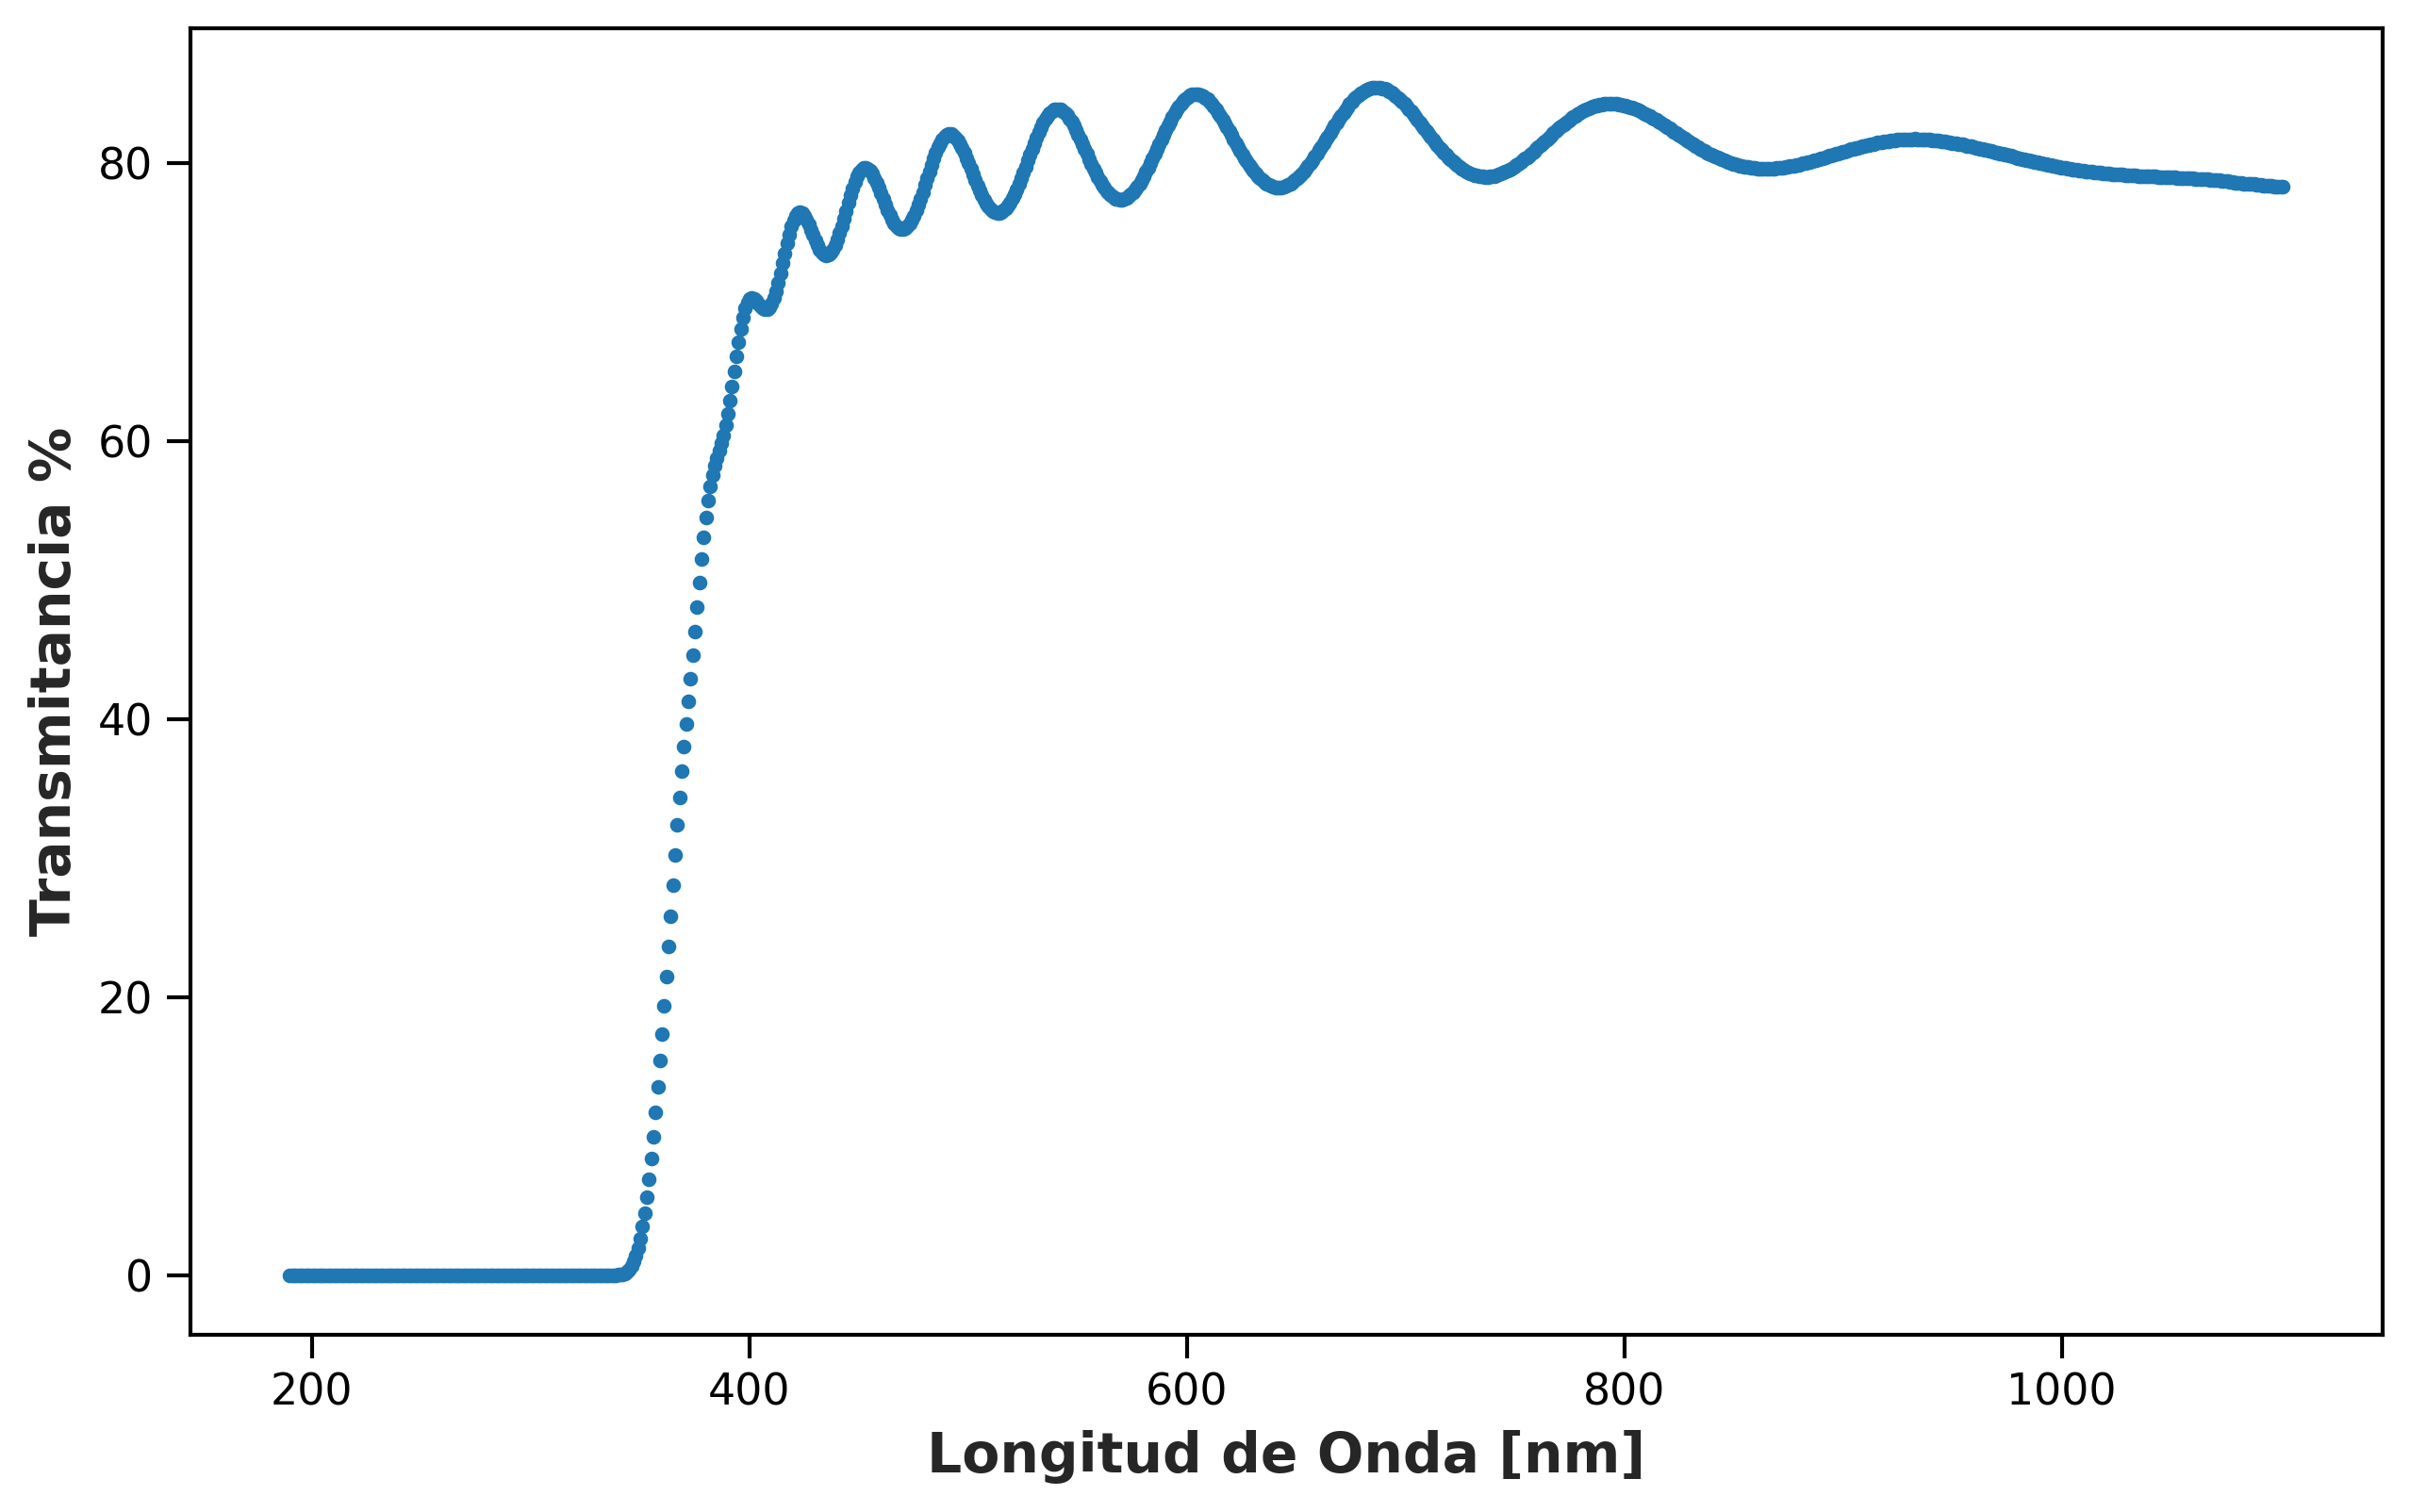

In [53]:
n = random.randint(0, df_final.shape[0]-1)
plot_unico(x, df_final['Espectro'][n])

# Save DF

In [54]:
df_final.shape

(240000, 7)

In [55]:
df_final.to_parquet('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/NewDataAzONetV2/bin_{}.parquet'.format(bint), index = False)